# Coronavirus Exceedance Probability

- **Summary**: This document uses the joint respiratory viral exceedance curve and the influenza exceedance curve to derive the coronavirus exceedance curve.

- **Data Required:** `epidemics_marani_240816.xlsx`

- **Author**: Ganqi Li (ganqi.li.25@dartmouth.edu)
- **Updated**: Sep 13, 2024

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.integrate import quad
from scipy.stats import genpareto
from scipy.optimize import minimize

## repeated printouts
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [ ]:
# Set filepaths
rawdata_dir = Path("../../data/raw").resolve()
cleandata_dir = Path("../../data/clean").resolve()
figdir = Path("../../output/exceedance_figures").resolve()

## 0. Prepare respiratory viral epidemic data

In [2]:
## Read epidemic data from Marani et al. 
df = pd.read_excel(rawdata_dir / "epidemics_marani_240816.xlsx")
df = df.sort_values(by='year_start', ascending=True).reset_index(drop=True)


In [3]:
## Subset data to 1600-present
yrmin = 1900
df = df[(df["year_start"] >= yrmin)].reset_index(drop=True)


In [4]:
## Subset to respiratory viral epidemics
df_resp_viral = df[df['disease'].isin(['influenza', 'covid-19', 'mers', 'sars'])
                  ].reset_index(drop=True)

## Subset to influenza epidemics
df_flu = df[df['disease'].isin(['influenza'])
                  ].reset_index(drop=True)

## 1. Set up a grid of severities

In [5]:
## Set severeity points automatically 
plot_madhav_points = False  ## CHANGE METHOD HERE

if plot_madhav_points:
    severity = [0.01, 7.2, 28, 45, 86, 150, 200, 220, 250, 280]
else:
    severity = [0.01, 0.04, 0.07, 0.08, 0.1, 0.4, 0.7, 1, 4, 7, 8, 10, 
                15, 20, 28, 40, 45, 70, 86, 100, 120, 150, 170, 190, 
                200, 220, 230, 240, 250, 260, 270, 280]

In [6]:
## Set severity threshold to 0.01 SMU
thresh = 0.01

In [7]:
## Subset to threshold-exceeding epidemics
df_resp_viral_exceed = df_resp_viral[df_resp_viral['severity_smu'] >= thresh].reset_index(drop=True)
df_flu_exceed = df_flu[df_flu['severity_smu'] >= thresh].reset_index(drop=True)


## 3. Calibrate respiratory viral exceedance

In [8]:
## Fit generalized Pareto distribution on severe epidemics
params_resp = genpareto.fit(df_resp_viral_exceed['severity_smu'], floc=thresh)

## Print results
print(params_resp)

(1.3911490201494356, 0.01, 4.919578645628762)


In [9]:
## Find arrival rate of threshold-exceeding epidemics during 2000 to 2019
arrival_resp_viral_exceed = df_resp_viral_exceed[(df_resp_viral_exceed['year_start'] >= 2000) & 
                                                 (df_resp_viral_exceed['year_start'] <= 2019)
                                                ].shape[0] / 20

## Print arrival rate of threshold-exceeding events
print(f'Extreme respiratory epidemic arrival rate: {round(arrival_resp_viral_exceed, 3)}/year')


Extreme respiratory epidemic arrival rate: 0.1/year


## 4. Calibrate influenza exceedance

In [10]:
## Fit generalized Pareto distribution on severe epidemics
params_flu = genpareto.fit(df_flu_exceed['severity_smu'], floc=thresh)

## Print results
print(params_flu)

(1.8380521236515504, 0.01, 3.2254229231228875)


In [11]:
## Find arrival rate of threshold-exceeding epidemics during 2000 to 2019
arrival_flu_exceed = df_flu_exceed[(df_flu_exceed['year_start'] >= 2000) & 
                                   (df_flu_exceed['year_start'] <= 2019)
                                  ].shape[0] / 20

## Print arrival rate of threshold-exceeding events
print(f'Extreme influenza epidemic arrival rate: {round(arrival_flu_exceed, 3)}/year')

Extreme influenza epidemic arrival rate: 0.05/year


## 5. Calculate coronavirus exceedance

In [12]:
## Calculate exceedance probabilities
exceedance_resp = arrival_resp_viral_exceed * (1 - genpareto.cdf(severity, 
                                                                *params_resp))

exceedance_flu = arrival_flu_exceed * (1 - genpareto.cdf(severity, 
                                                        *params_flu))


df_cov = pd.DataFrame({
    "severity": severity,
    "exceedance_resp": exceedance_resp,
    "exceedance_flu": exceedance_flu
})

## Sort and reset index (optional)
df_cov = df_cov.sort_values(by='severity', ascending=True)
df_cov = df_cov.reset_index(drop=True)


In [13]:
## Calculate coronavirus exceedance
# df_cov['exceedance_cov'] = (
#     (df_cov['exceedance_resp'] - df_cov['exceedance_flu']) 
#     / (1 - df_cov['exceedance_flu'])
# )  ## if independent


df_cov['exceedance_cov'] = (
    df_cov['exceedance_resp'] - df_cov['exceedance_flu']
) ## if mutually exclusive


## 6. Visualize comparison

<Figure size 1000x600 with 0 Axes>

Text(0.5, 0, 'Epidemic severity (SMU = deaths per 10,000 people)')

Text(0, 0.5, 'Annual exceedance probability (log scale)')

(0.0001, 1.0)

(0.0, 300.0)

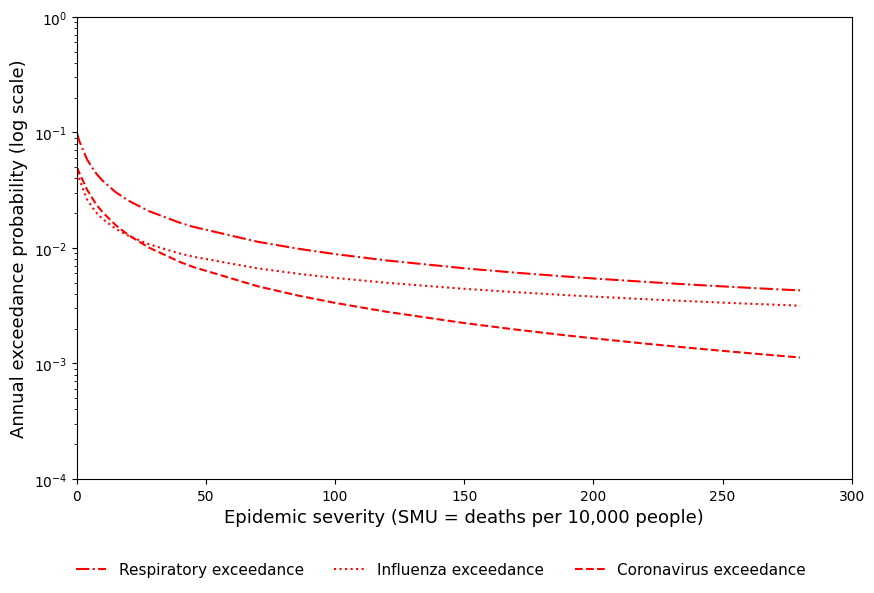

In [14]:
## Plot comparison across Marani with different thresholds 
plt.figure(figsize=(10, 6))


## Plot for resp viral with 0.01 SMU threshold
plt.plot(df_cov['severity'], df_cov['exceedance_resp'], 
         color='red', linestyle='-.', alpha=1,
         label='Respiratory exceedance')


## Plot for flu with 0.01 SMU threshold
plt.plot(df_cov['severity'], df_cov['exceedance_flu'], 
         color='red', linestyle=':', alpha=1,
         label='Influenza exceedance')


## Plot for cov with 0.01 SMU threshold
plt.plot(df_cov['severity'], df_cov['exceedance_cov'], 
         color='red', linestyle='--', alpha=1,
         label='Coronavirus exceedance')


# ## Plot for Madhav
# plt.plot(df_madhav['severity'], df_madhav['exceedance'], 
#          color='purple', linestyle='-', label='Original simulated results from Madhav')


## Add labels and title
# plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people) (log scale)', fontsize=13)
plt.xlabel('Epidemic severity (SMU = deaths per 10,000 people)', fontsize=13)
plt.ylabel('Annual exceedance probability (log scale)', fontsize=13)
# plt.title('Coronavirus Exceedance', fontsize=16)

## Set y-axis scale and limits
plt.yscale('log')
plt.ylim(1e-4, 1e0)

## Set x-axis scale and limits
# plt.xscale('log')
# plt.xlim(1e-2, 1e3)
plt.xlim(0, 300)

## Adding legend below the plot in 'ncol' column(s) without frame
plt.legend(loc='upper center', bbox_to_anchor=(0.47, -0.15), 
           ncol=3, frameon=False, fontsize=11)

## Save graph as jpg file at 400 dpi
plt.savefig(figdir / '08_cov_exceedance.jpg', dpi=400, bbox_inches = 'tight')

## Display
plt.show()


## 7. Explore expected loss by truncating severity

If we use lower and upper bound severity truncations, respectively at $s_{min}$ and $s_{max}$, then we can calculate the annual expected loss as

<p align="center">
\[
\mathbb{E}(s) = r_{\mu} \cdot \left(\int_{s_{min}}^{s_{max}} x \cdot f(x) dx + [1-F(s_{max})] \cdot s_{max} \right),
\]
</p>

where $r_{\mu}$ is the threshold-exceeding arrival rate, $f(s)$ is the PDF of threshold-exceeding severity under a generalized Pareto fit, and $F(s)$ is the CDF of threshold-exceeding severity.



In [26]:
## Define truncation boundaries (SMUs)
severity_min = 0.01
severity_max = 380


In [27]:
## Define PDF for respiratory
def pdf(x):
    return genpareto.pdf(x, *params_resp)

## Define CDF for respiratory
def cdf(x):
    return genpareto.cdf(x, *params_resp)

## Define expected value integrand
def expected_value_integrand(x):
    return x * pdf(x)

## Calculate integral from severity_min to severity_max
integral_value, error = quad(expected_value_integrand, 
                             severity_min, severity_max)

## Calculate point mass contribution at severity_max
point_mass_contribution = severity_max * (1 - cdf(severity_max))

## Calculate total expected value for respiratory
expected_value_resp = arrival_resp_viral_exceed * (integral_value + point_mass_contribution)


In [28]:
## Define PDF for flu
def pdf(x):
    return genpareto.pdf(x, *params_flu)

## Define CDF for flu
def cdf(x):
    return genpareto.cdf(x, *params_flu)

## Define expected value integrand
def expected_value_integrand(x):
    return x * pdf(x)

## Calculate integral from severity_min to severity_max
integral_value, error = quad(expected_value_integrand, 
                             severity_min, severity_max)

## Calculate point mass contribution at severity_max
point_mass_contribution = severity_max * (1 - cdf(severity_max))

## Calculate total expected value for influenza
expected_value_flu = arrival_flu_exceed * (integral_value + point_mass_contribution)


In [29]:
## Calculate total expected value for coronaviruses
expected_value_cov = expected_value_resp - expected_value_flu


In [30]:
## Print results
print("Annual Average Losses")
print(f"GPD fitted on {yrmin}-present data")
print(f"Truncation: {severity_min}-{severity_max}")
print()

print(f"Respiratory epidemics: {round(expected_value_resp, 3)} SMU")
print()

print(f"Influenza epidemics: {round(expected_value_flu, 3)} SMU")
print()

print(f"Coronavirus epidemics: {round(expected_value_cov, 3)} SMU")
print()


Annual Average Losses
GPD fitted on 1900-present data
Truncation: 0.01-380

Respiratory epidemics: 3.44 SMU

Influenza epidemics: 2.047 SMU

Coronavirus epidemics: 1.393 SMU



In [31]:
df_resp_viral_exceed

,location,year_start,year_end,duration,death_thousand,pop_thousand,severity_perthousand,severity_smu,disease,type,transmission,is_vira_only,is_vira_mixed,contains_vira,is_pandemic
0,pandemic spanish flu,1918,1920,3,32000.0,1873300.0,17.082154,170.821545,influenza,viral,droplet,1,0,1,1
1,pandemic of asian flu,1957,1958,2,2000.0,2873306.0,0.696062,6.960623,influenza,viral,droplet,1,0,1,1
2,hong kong flu,1968,1969,2,1000.0,3551599.0,0.281563,2.815633,influenza,viral,droplet,1,0,1,1
3,swine flu,2009,2009,1,284.5,6872767.0,0.041395,0.413953,influenza,viral,droplet,1,0,1,1
4,global covid-19,2019,2024,6,7100.0,7740000.0,0.917313,9.173127,covid-19,viral,airborne/droplet,1,0,1,1
